In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [ ]:
np.random.seed(42)
random.seed(42)

# --- Simulated vehicle feedback dataset ---
positive_phrases = [
    "smooth ride and great mileage", "excellent build quality", "love the fuel efficiency",
    "very comfortable seats", "amazing acceleration and handling", "quiet cabin and smooth engine",
    "great value for money", "impressive safety features", "reliable and low maintenance",
    "fantastic infotainment system"
]
negative_phrases = [
    "engine makes a lot of noise", "poor fuel economy", "uncomfortable seats on long drives",
    "brakes feel weak and spongy", "too many issues after purchase", "bad after sales service",
    "suspension is too stiff", "interior quality feels cheap", "frequent electrical problems",
    "disappointed with the mileage"
]

In [ ]:
n = 1000
rows = []
for _ in range(n):
    if random.random() < 0.5:
        text = random.choice(positive_phrases)
        label = 1
    else:
        text = random.choice(negative_phrases)
        label = 0
    # add small random word-order noise so texts aren't identical duplicates
    words = text.split()
    if len(words) > 3 and random.random() < 0.3:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    rows.append((" ".join(words), label))

In [ ]:
feedback_df = pd.DataFrame(rows, columns=["review", "sentiment"])
print(feedback_df["sentiment"].value_counts())
feedback_df.head()

sentiment
0    502
1    498
Name: count, dtype: int64


,review,sentiment
0,engine makes a lot of noise,0
1,love the fuel efficiency,1
2,frequent electrical problems,0
3,money value for great,1
4,fantastic infotainment system,1


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

VOCAB_SIZE = 500
MAX_LEN = 12

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(feedback_df["review"])

sequences = tokenizer.texts_to_sequences(feedback_df["review"])
padded = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")

X_train, X_test, y_train, y_test = train_test_split(
    padded, feedback_df["sentiment"].values, test_size=0.2, random_state=42, stratify=feedback_df["sentiment"])

print("Vocabulary size used:", len(tokenizer.word_index))
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Vocabulary size used: 68
Train shape: (800, 12) | Test shape: (200, 12)


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=8,
    batch_size=32,
    verbose=1
)

Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4838 - loss: 0.6933 - val_accuracy: 0.4833 - val_loss: 0.6902
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.6632 - loss: 0.6739 - val_accuracy: 0.8833 - val_loss: 0.6151
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9662 - loss: 0.3974 - val_accuracy: 1.0000 - val_loss: 0.1127
Epoch 4/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9985 - loss: 0.0789 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 5/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9985 - loss: 0.0188 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 6/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9985 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 7/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9926 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9985 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss:

Test Accuracy: 1.000 | Test Loss: 0.001
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       100
    Positive       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



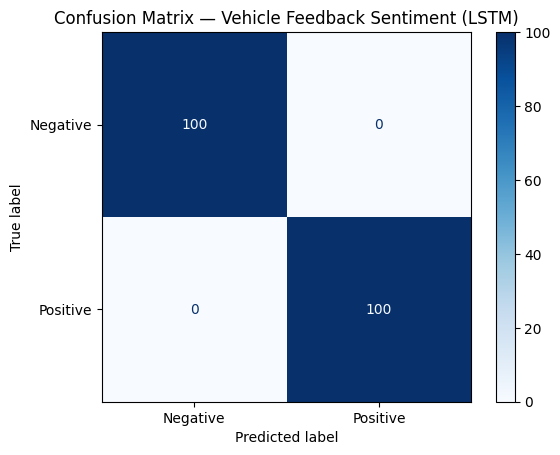

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.3f} | Test Loss: {test_loss:.3f}")

y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).ravel()
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Vehicle Feedback Sentiment (LSTM)")
plt.show()

In [ ]:
# Quick manual test on new, unseen feedback
sample_reviews = [
    "the mileage is excellent and ride is smooth",
    "brakes are weak and service was terrible",
    "very comfortable and quiet cabin"
]
seqs = tokenizer.texts_to_sequences(sample_reviews)
padded_sample = pad_sequences(seqs, maxlen=MAX_LEN, padding="post")
preds = model.predict(padded_sample, verbose=0)

for text, p in zip(sample_reviews, preds):
    label = "Positive" if p[0] > 0.5 else "Negative"
    print(f"[{label} ({p[0]:.2f})] {text}")

[Positive (1.00)] the mileage is excellent and ride is smooth
[Negative (0.00)] brakes are weak and service was terrible
[Positive (1.00)] very comfortable and quiet cabin
